****TITANIC DATASET****

**1. Data Loading & Cleaning**

In [1]:
# Step 1: Data Loading & Cleaning
import pandas as pd
import seaborn as sns  

# Load Titanic dataset
titanic = sns.load_dataset('titanic')
display(titanic.head())  # Display the first few rows
print(titanic.info())    # Show the data types and non-null counts
print("\nMissing values:\n", titanic.isnull().sum())  # Check missing values

# Clean data - handle missing values
# Drop 'deck' column with too many missing values
titanic.drop(columns=['deck'], inplace=True)

# Impute missing categorical values with mode (most frequent value)
for col in ['embarked', 'embark_town']:
    titanic[col].fillna(titanic[col].mode()[0], inplace=True)

# Impute missing 'age' with the mean
titanic['age'].fillna(titanic['age'].mean(), inplace=True)

print("\nAfter cleaning, missing values:\n", titanic.isnull().sum())  # Check again for missing data


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

Missing values:
 survived         0
pclass           0
sex              0

C:\Users\PMYLS\AppData\Local\Temp\ipykernel_38004\869851111.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic[col].fillna(titanic[col].mode()[0], inplace=True)
C:\Users\PMYLS\AppData\Local\Temp\ipykernel_38004\869851111.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

**2. EDA (Exploratory Data Analysis) Visualizations**

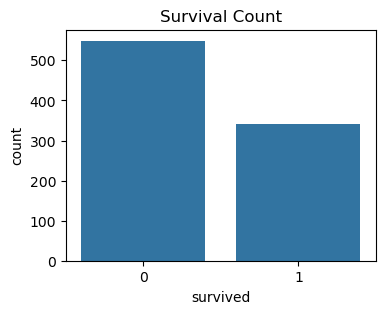

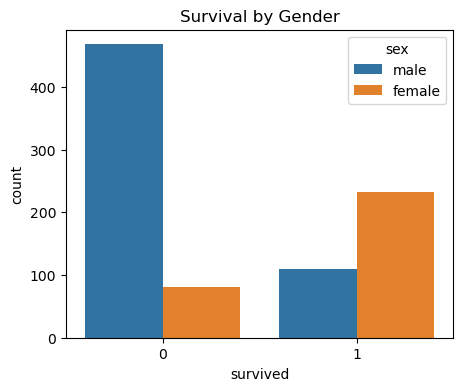

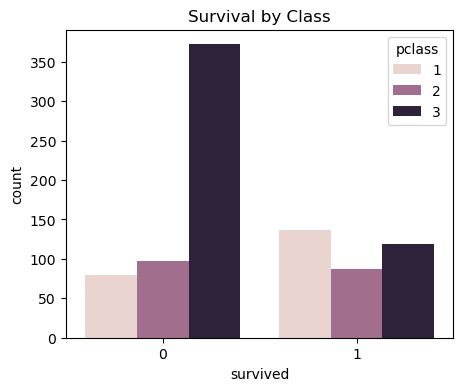

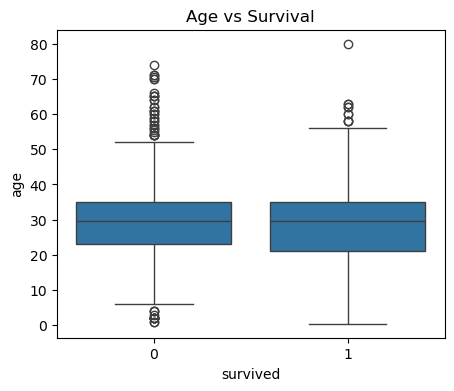

In [2]:
# Step 2: EDA Visualizations
import seaborn as sns
import matplotlib.pyplot as plt

# Count plot for survival
plt.figure(figsize=(4,3))
sns.countplot(x='survived', data=titanic)
plt.title('Survival Count')
plt.show()

# Count plot by gender and survival
plt.figure(figsize=(5,4))
sns.countplot(x='survived', hue='sex', data=titanic)
plt.title('Survival by Gender')
plt.show()

# Count plot by class and survival
plt.figure(figsize=(5,4))
sns.countplot(x='survived', hue='pclass', data=titanic)
plt.title('Survival by Class')
plt.show()

# Boxplot for age vs survival
plt.figure(figsize=(5,4))
sns.boxplot(x='survived', y='age', data=titanic)
plt.title('Age vs Survival')
plt.show()


**3. Feature Engineering & Statistical Tests**

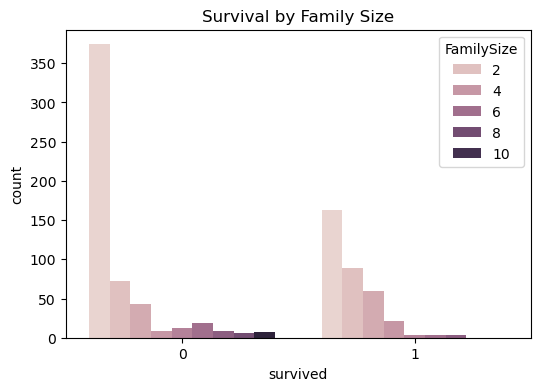

sex vs Survived: χ²=260.7, p=0.0000
pclass vs Survived: χ²=102.9, p=0.0000
FamilySize vs Survived: χ²=80.7, p=0.0000

Age t-test: t=-2.1, p=0.0372


In [3]:
# Step 3: Feature Engineering & Statistical Tests

# Adding a FamilySize feature
titanic['FamilySize'] = titanic['sibsp'] + titanic['parch'] + 1

# Plot survival vs FamilySize
plt.figure(figsize=(6,4))
sns.countplot(x='survived', hue='FamilySize', data=titanic)
plt.title('Survival by Family Size')
plt.show()

# Chi-square test for categorical variables with survival
from scipy.stats import chi2_contingency

def chi2_test(col):
    table = pd.crosstab(titanic[col], titanic['survived'])
    chi2, p, *_ = chi2_contingency(table)
    print(f"{col} vs Survived: χ²={chi2:.1f}, p={p:.4f}")

# Apply chi-square to features
for feature in ['sex', 'pclass', 'FamilySize']:
    chi2_test(feature)

# Age t-test (Survived vs Not Survived)
from scipy.stats import ttest_ind

ages_surv = titanic.loc[titanic.survived==1, 'age']
ages_not = titanic.loc[titanic.survived==0, 'age']
t_stat, p_val = ttest_ind(ages_surv, ages_not, nan_policy='omit')
print(f"\nAge t-test: t={t_stat:.1f}, p={p_val:.4f}")


**4. Encoding & Correlation**

Encoded shape: (891, 19)


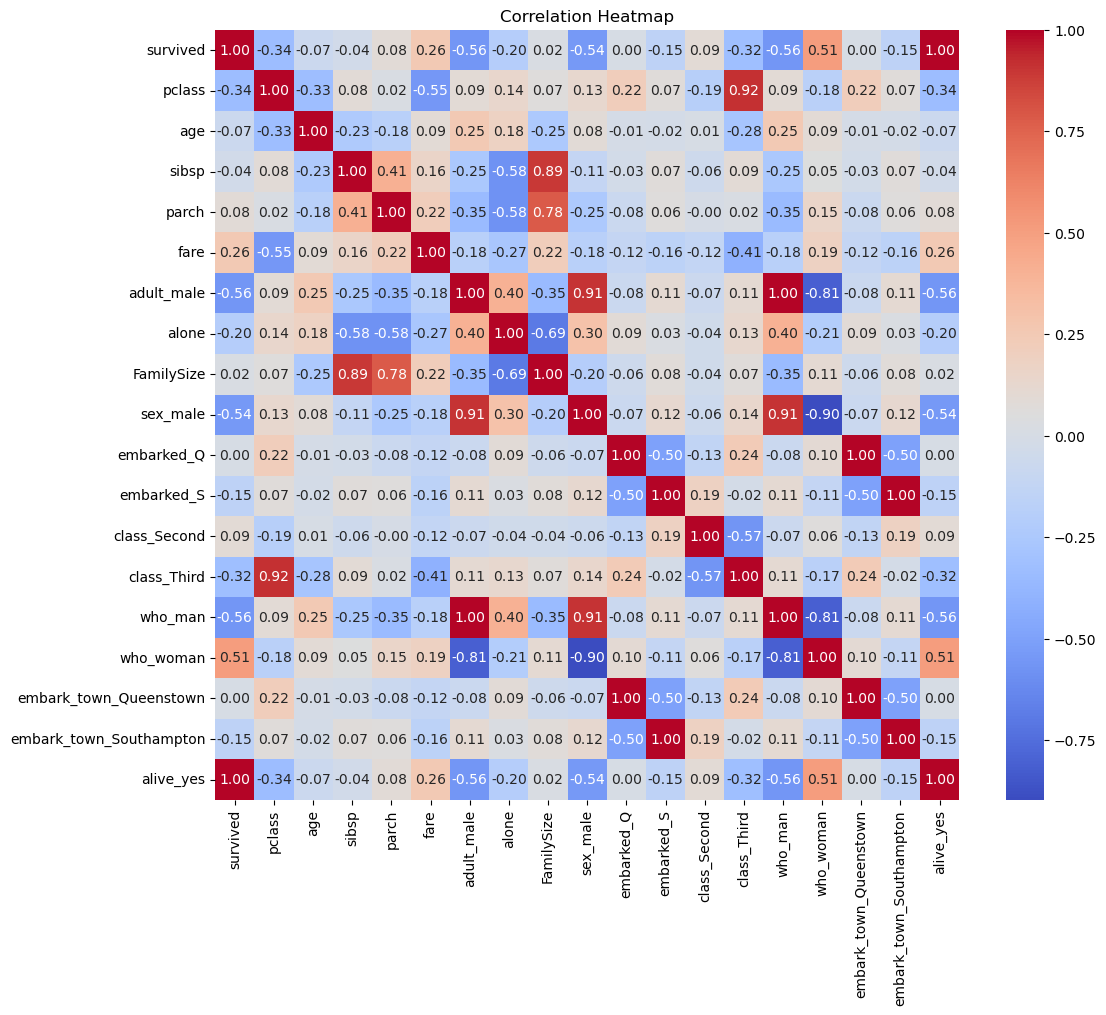

In [4]:
# Step 4: Encoding & Correlation
# One-hot encode categorical features
titanic_encoded = pd.get_dummies(titanic, drop_first=True)

# Check shape after encoding
print("Encoded shape:", titanic_encoded.shape)

# Plot correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(titanic_encoded.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


**5. Baseline Random Forest Model (Hold-out + Cross-Validation)**

In [5]:
# 1. Drop the leakage column before encoding
titanic.drop(columns=['alive'], inplace=True)

# 2. Re-create FamilySize (in case you rerun from scratch)
titanic['FamilySize'] = titanic['sibsp'] + titanic['parch'] + 1

# 3. One-hot encode all remaining categoricals
cat_cols = titanic.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
titanic_encoded = pd.get_dummies(titanic, columns=cat_cols, drop_first=True)

# 4. Prepare X and y
X = titanic_encoded.drop('survived', axis=1)
y = titanic_encoded['survived']

# 5. Train/test split and Random Forest as before
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier   
from sklearn.metrics import accuracy_score  # Import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 6. Evaluate on hold-out set
y_pred = rf.predict(X_test)
print("Hold-out accuracy:", accuracy_score(y_test, y_pred))

# 7. Cross-validate for a more robust score
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print("5-fold CV accuracies:", cv_scores)
print("CV mean accuracy:", cv_scores.mean())


Hold-out accuracy: 0.8268156424581006
5-fold CV accuracies: [0.79329609 0.79213483 0.84269663 0.78089888 0.83707865]
CV mean accuracy: 0.8092210156299041


**Step 6: Confusion Matrix & ROC AUC**

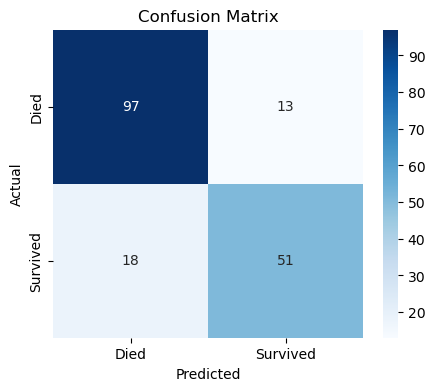

ROC AUC: 0.826548089591568


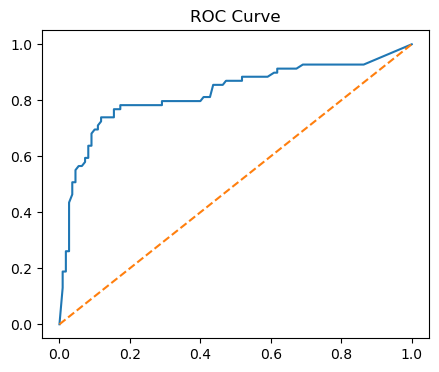

In [6]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died','Survived'],
            yticklabels=['Died','Survived'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC AUC
y_prob = rf.predict_proba(X_test)[:,1]
print("ROC AUC:", roc_auc_score(y_test, y_prob))

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title('ROC Curve')
plt.show()
